# 연관분석  

## 1. 연관분석이란?  
> 연관분석 : 상품이나 서비스를 구매하는 등 일련의 거래나 사건안에 존재하는 항목간의 일정한 연관 규칙을 발견하는 분석  

*e.g.)* 
- OTT 서비스 : 사용자의 시청 패턴을 분석하여 맞춤 콘텐츠 추천
- 금융기관 : 거래패턴을 통해 사기 행위 탐지 및 맞춤 금융 상품 기획  
- 의료 분야 : 환자의 증상 및 질병 패턴을 분석하여 예방 조치 마련  
- 요식업계 : 인기 메뉴 조합을 찾아 세트메뉴 개발  

-> 정답값이 존재하지 않기에 비지도 학습에 해당
연관분석 알고리즘으로(Apriori, FP-Growth) 존재  

### **연관규칙 분석**  
> 연관규칙의 형태 : 'A를 구매하였을 때, B 또한 구매할 것이다' 와 같이 if - then의 형식을 띄고 A->B로 표현  
- 조건절(Antecedent) : '만일 ~라면'에 해당하는 부분(If~)
- 결과절(Consequent) : 그 뒷부분에 해당하는 내용(then~)    
- 아이템 집합(Item Set) : 조건절 또는 결과절을 구성하는 아이템들의 집합(mutually exclusive)  

*ex) 라면을 구매하는 사람들은 달걀도 함께 산다.*
조건절 : 라면 구매 / 결과절 : 달걀 구매 / 아이템 집합 : 라면, 달걀    

### **연관규칙 주의**  
연관규칙으로는 상관관계를 파악할 뿐, **인과관계**는 알 수 없다  
*ex) A->B의 신뢰도 = 0.8* -> 'A를 산 사람 중 80%는 B도 샀다'일뿐 A를 사서 B를 산 인과관계는 알수 없음!  


## 2. 주요개념  

### 2-1. (적절한) 연관규칙의 조건  
**1. 두 품목이 함께 구매한 경우의 수가 일정 수준 이상이어야 함(일정 이상의 지지도)**  

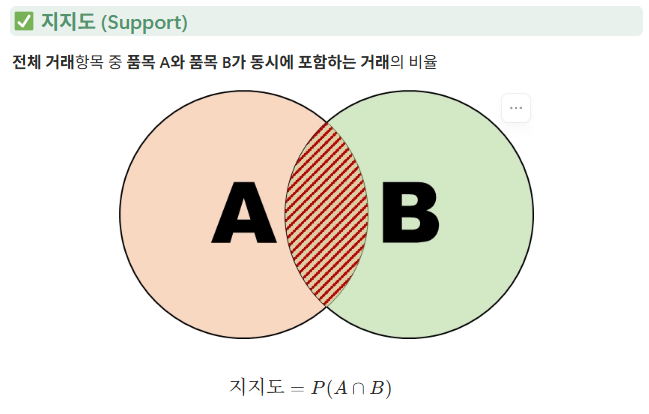  

**지지도(Support)가 낮다면?**  
- 우연으로 인한 규칙일 가능성 존재 -> 통계적 신뢰도 없음  
- 실행 가능한 인사이트 도출 어려움  

*i.e.* 이 규칙이 현실에서 의미 있는가? 를 판단하는 1차적 기준  



**2. A를 포함하는 거래 중 B를 구입하는 경우의 수가 일정수준 이상이어야 함(일정 이상의 신뢰도)**   

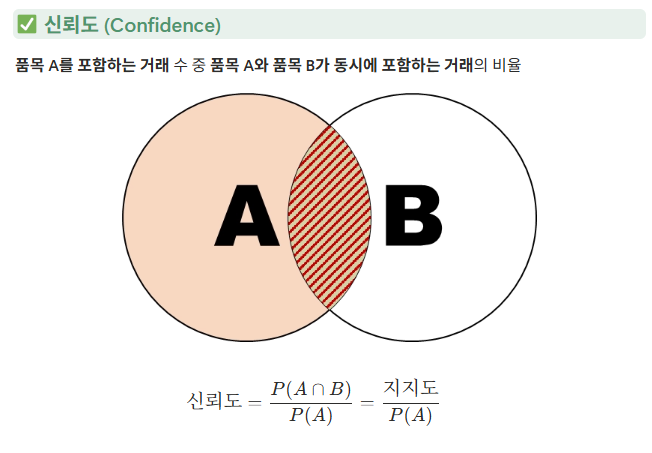  

**신뢰도(Confidence)가 낮다면?**  
- 의미 없는 연관 규칙 (A를 사더라도 B는 잘 안사는 경우) -> 의미 퇴색  
- 추천실패 : 신뢰도가 낮은 규칙을 기반으로 추천 or 마케팅 타겟팅 -> 클릭률, 전환율 모두 낮아짐

*i.e.* A가 일어났을 때, B도 일어날것이라고 얼마나 확신할수 있는가?


### 2-2. 연관 분석의 평가 측도  
 >향상도(Lift) : A가 주어지지 않았을 때의 B의 확률 대비, A가 주어졌을때의 B의 확률의 증가비율   

Idea : "A와 B가 우연히 함께 등장할 확률과 실제 함께 등장할 확률 비교"  

$향상도 = \frac{P(A \cap B)}{P(A)P(B)} = \frac{신뢰도}{P(B)}$  

1. 기댓값
 - 두 사건이 독립 -> 향상도 = 1  
    $향상도 = \frac{P(A \cap B)}{P(A)⋅P(B)} = \frac{P(A)⋅P(B)}{P(A)⋅P(B)}=1$  

 - 두 사건이 독립이 아닌 경우  
    - A를 샀다는 사실이 B를 살 확률에 영향을 주거나 역의 관계 존재  
    - 실제로 관측한 $P(A\cap B)$ 에 따라 향상도는 1보다 크거나 작은값을 가짐    

2. 실제 동시 발생 확률  
 - 실제로 관측한 $P(A\cap B)$가 $P(A) \cdot P(B)$보다  
    - 크면 -> 양의 연관성 (A사면 B도 잘 삼)  
    - 작으면 -> 음의 연관성 (A 산 사람은 B 잘 안삼)   

3. 비율로 비교 -> 향상도  

| 향상도 > 1 | 우연적 기회보다 높은 확률 (두 품목이 서로 양의 상관관계) |   
|---|---|   
| 향상도 = 1 | 독립 |   
| 향상도 < 1 | 우연적 기회보다 낮은 확률 (두 품목이 서로 음의 상관관계) |   

규칙의 효용성은 지지도, 신뢰도, 향상도 3가지를 모두 반영하여 평가  
임의의 규칙1이 규칙2보다 효과적이다 : 세 지표가 모두 큰 경우메만 맞는 말  

**적용 예시**  
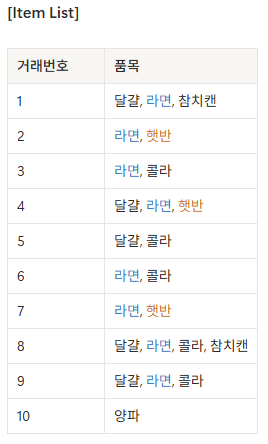   

총 규칙 수 = $3^n - 2^{n+1} +1$  
- 지지도 = $P(라면 \cap 햇반) = \frac{3}{10} = 0.3$  
- 신뢰도 = $P(햇반|라면) = \frac{3}{8} = 0.375$  
- 향상도 = $\dfrac{P(라면 \cap 햇반)}{P(라면) \cdot P(햇반)} = \frac{0.3}{0.8 * 0.3} = 1.25 $  
->향상도는 우연적 기회보다 높을 확률 :  향상도 > 1이므로 양의 상관관계  
*i.e.* 라면을 구매한 고객이 라면을 구매하지 않은 고객에 비해 햇반을 구매할 확률이 25%높다  



## 3.연관분석 활용사례  

2004년 8월, 허리케인 프랜시스가 플로리다 해안으로 접근하였던 상황.  
대부분의 유통업체가 생수와 손전등을 채워 넣은 반면 당시 CIO였던 린다 딜먼은 몇 주 전 플로리다를 강타했던 허리케인 찰리 당시의 판매 데이터를 분석하도록 지시했고, 사후 대응이 아니라 사전 예측으로 전환해야 할 때라고 판단.  
목표는 생수·건전지처럼 뻔한 품목이 아니라, 아무도 예상하지 못한 패턴을 찾는 것  
월마트는 수조 바이트에 달하는 구매 이력을 뒤진 결과 딸기맛 팝타르트가 폭풍 전에 잘 팔렸던것을 인지  

- 딸기맛 팝타르트는 허리케인 직전에 평상시의 약 7배 속도로 팔렸다   
- 허리케인 직전 판매 1위 품목은 맥주  
- 팝타르트는 가열이 필요 없고, 냉장 보관이 필요 없으며, 유통기한이 매우 길다 → 정전 상황에 최적화된 식품  

위 상황을 연관분석 관점에서 해석하면?  

1. 지지도 (Support)
- 예시 : 
    - "허리케인 경보 기간 중 발생한 전체 거래 중에서 '생수·건전지 등 재난 대비 용품'과 '딸기 팝타르트'가 함께 담긴 장바구니의 비중"
        → 평상시에는 지지도가 낮았지만, 허리케인 상황에서는 이 조합의 지지도가 크게 상승.  
- 해석 : 월마트는 특정 조건(재난 경보) 하에서만 유의미해지는 조합을 찾아냈음. 전체 기간을 통으로 분석했다면 묻혔을 규칙이라는 점이 핵심.

2. 신뢰도 (Confidence)
- 예시 : 
    - A: 허리케인 대비 물품(생수, 건전지, 손전등)을 구매  
    - B: 딸기 팝타르트를 함께 구매  
        → P(B|A)가 충분히 높았다는 것, 즉 재난 대비 장바구니에는 팝타르트가 따라 들어오는 경향이 있다는 의미.  
- 해석 : "재난 대비 고객은 조리가 필요 없는 간편식을 함께 산다 → 이 품목을 함께 진열·비축하면 매출로 직결된다"고 판단.  

3. 향상도 (Lift)  
- 예시 :  
    - A: 허리케인 경보 발령 상황  
    - B: 딸기 팝타르트 구매  
    - 평상시 구매 확률 대비 약 7배 → Lift ≈ 7, 즉 1보다 훨씬 큼  
- 해석 : A와 B는 명백히 독립이 아니며, 두 사건 사이에 강한 양의 상관이 존재. 월마트는 "왜 하필 딸기맛인가"라는 인과를 설명하지 못했지만, 향상도가 높다는 사실만으로 물류 의사결정을 실행. 연관 분석이 인과가 아닌 동시 발생 패턴을 다루는 기법이라는 점을 보여주는 좋은 사례.



## 4.연관분석의 알고리즘  

### 4-1 Apriori 알고리즘    
> **배경 : 무차별 탐색의 비효율**  
- 연관 규칙을 찾기 위해 가능한 모든 조합을 시도하는것은 비효율적  
    - 가능한 조합 : A(선행조건) -> B(결과조건) 로 표현되도록 하는 모든 경우의 수  
    - A, B는 단일이 아니라 복합 조건도 가능  
- 상품의 수가 많아질수록 조합의 수 기하급수적으로 증가(지수)  

> **Apriori 알고리즘 소개**  
- 개념 : 상위 조합에서부터 차례로 스캔하며, 특정 조합이 자주 발생하지 않는다면 이의 결과물로 탄생한 후속 조합까지 후보에서 배제하는 알고리즘  
- 장점 : Apriori 알고리즘을 활용하면 하나의 조합만 검사하고도 이에서 파생된 다른 조합까지 후보에서 배제하여 시간과 연산량을 효과적으로 줄일 수 있다  

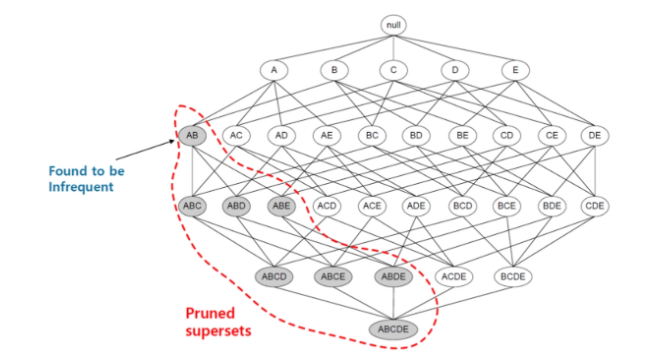  

{A, B}의 지지도가 기준을 넘지 못하면, {A,B,~}는 고려대상이 아님!  

> Apriori 알고리즘 프로세스  
1. 단일 항목 집합 생성  
    1. 모든 개별 상품에 대해 지지도 계산  
    2. 최소 지지도를 넘는 항목들만 다음 단계로  

2. 2개 항목 집합 생성  
    1. 1단계에서 선별된 상품들로 2개 항목의 조합을 생성  
    2. 이 조합에 대해 지지도를 계산하고, 최소 지지도를 넘지 않는 조합을 제거  

3. 더 큰 항목 집합 생성  
    1. 이전 단계에서 남은 조합들을 바탕으로 3개 이상의 항목으로 구성된 조합을 생성  
    2. 지지도를 계산하고, 최소 지지도를 넘지 않는 조합 제거  
    3. 더 이상 조합을 생성할 수 없을때까지 이 과정 반복  

4. 최종 빈발 항목 집합 선정  
    1. 마지막으로 남은 빈발 항목 집합들을 바탕으로 연관규칙 생성  
    2. 각 규칙에 대해 지지도, 신뢰도, 향상도를 계산하여 가장 유용한 규칙 선택  

*빈말 항목 집합 : 일정한 최소 지지도를 넘는 항목들의 조합*

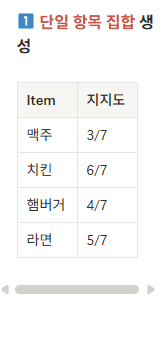 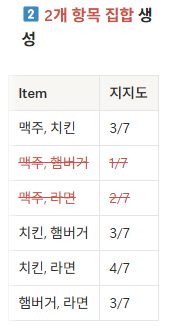   

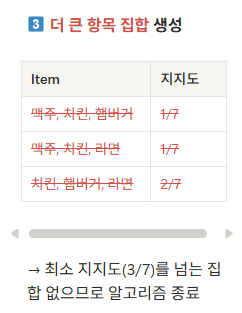 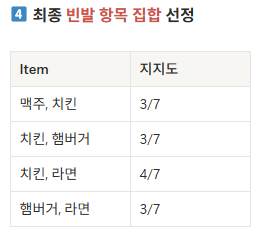  

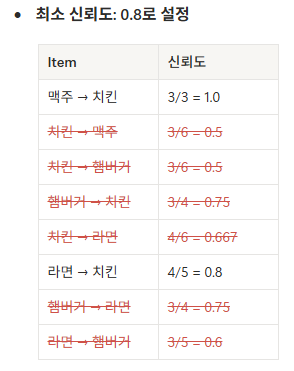 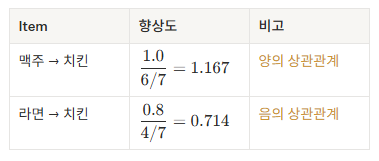  


**Apriori 장단점**  
장점
- 수많은 상품 연관 구매 패턴 발견  
- 원리가 간단, 이해분석 용이  

단점  
- 여전히 데이터가 커질수록 속도가 느려짐  


### 4-2 FP Growth 알고리즘  

> **배경 : 여전히 느리다**  
- Apriori 알고리즘은 여전히 데이터가 커질수록 속도가 느려진다는 단점 존재  
    - 각 단계에서 데이터를 다시 스캔해야 하기 때문

> **FP-Growth 알고리즘 소개**  
- FP-Growth(Frequent Pattern Growth) 알고리즘은 빈발 품목 집합을 효율적으로 찾아냄  
- FP-Tree라는 구조를 이용하여 Apriori를 효과적으로 구현  
- Tree, Array, Linked_List를 합쳐놓은 구조 

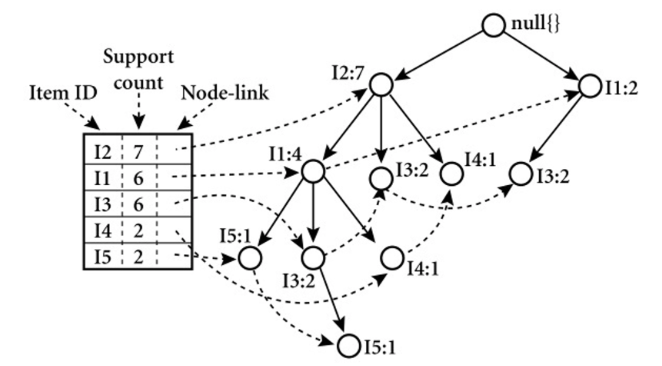  

- 모든 거래를 확인하여 각 아이템마다 지지도를 계산하고, 최소 지지도 이상의 아이템만 선택  
    - 모든 거레에서 빈도가 높은 아이템 순서대로 정렬  
    - 부모 노드를 중심으로 거래를 자식 노드로 추가하며 tree를 생성  
    - 새로운 아이템이 나올 경우 부모노드부터 시작, 그렇지 않으면 기존 노드에서 확장  
    - 위 과정을 모든 거래에 대해 반복하여 FP Tree를 만들고 최소 지지도 이상의 패턴만 추출  

> FP-Growth 알고리즘 프로세스  
1. 데이터셋 확인  
    - $D = [ \{초장\}^9, \{과메기\}^{40}, \{과메기, 김\}^{50}, \{과메기, 김, 초장\}^1]$  
    -> 초장만 산 사람 : 9명  
       과메기만 산 사람 : 40명  
       과메기&김 같이 산 사람 : 50명  
       과메기, 김, 초장 모두 산 사람 : 1명  


2. 빈도순 재정렬  
남은 항목들을 각 거래별로 빈도순으로 재정렬하여 거래 데이터에서 가장 자주 구매된 항목이 먼저 오도록 재정렬(called f-list)  
    1. 과메기 : 91 , 2. 김 : 51 , 3.초장 : 10

3. FP-Tree 생성  
 재정렬된 데이터를 바탕으로 FP-Tree생성
 각 거래를 노드로 표현하며, 동일한 항목은 기존 노드를 연결해 빈도를 증가시키고, 새로운 항목은 새로운 노드로 추가  

시작 node  
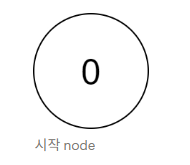  

{과메기,김} itemset추가  
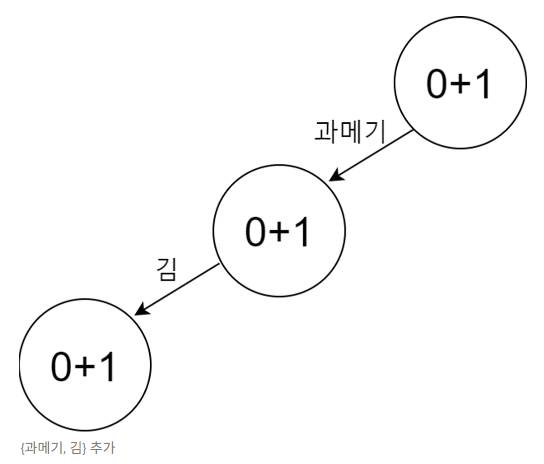  

...(동일한 방식으로 모든 Itemset 추가)


최종 node  
 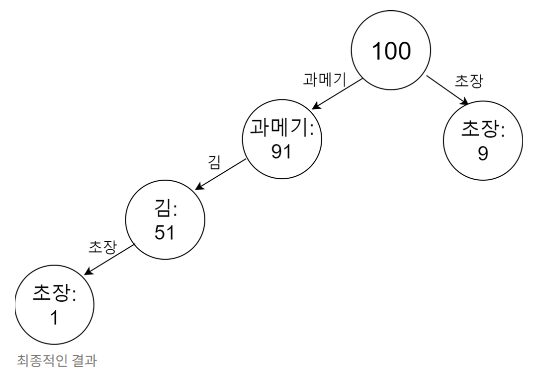


4. 빈말 항목 집합 추출  
FP-Tree를 바탕으로 특정 항목을 기준으로 부분 트리를 만들어 빈발 항목 집합을 추출한다.  
이 부분 트리에서는 기준이 된 항목과 연관된 빈발 항목 집합을 빠르게 도출할 수 있다.  


5. 연관 규칙 도출   
FP-Tree에서 도출된 빈발 항목 집합을 바탕으로 연관 규칙을 생성  
각 규칙에 대해 지지도, 신뢰도, 향상도 등의 지표를 계산하여 가장 유용한 규칙 선택

**FP-Growth 알고리즘 장단점**
장점  
- 데이터를 두 번만 스캔하는 Tree구조이기 때문에 Apriori보다 훨씬 빠름  
- 후보 Itemset을 생성할 필요 없이, Tree만 구성하면 끝  

단점  
- 대용량 데이터셋에서 메모리를 효율적으로 사용하지 않음  
- Apriori에 비해 설계하기 어렵고, 지지도의 계산은 무조건 FP-Tree가 만들어져야 가능  



- Apriori 알고리즘  
- FP Growth 알고리즘  

